In [2]:
import xarray as xr
import sys, os
from cloudpathlib import AnyPath

# Local Imports
curdir = os.getcwd()
sys.path.insert(0, curdir+"/../../../data_processing")
from ceres_ebaf import *
from ceres_syn import *

sys.path.insert(0, curdir+"/../../../visualization")
from ceres_ebaf_plotting import *

base_path = AnyPath("/Users/mawa7160/dev/data/CERES/")
full_ebaf_filename = "EBAF/CERES_EBAF_Edition4.1_200003-202203.nc"
syn_part_1 = "SYN/CERES_SYN1deg-Day_Terra-Aqua-MODIS_Ed4.1_Subset_20000301-20200325.nc"
syn_part_2 = "SYN/CERES_SYN1deg-Day_Terra-Aqua-MODIS_Ed4.1_Subset_20200326-20240229.nc"

plt.rcParams['figure.figsize'] = [10, 3.5]

# Load the full SYN1deg data
syn_part_1_data = xr.open_dataset(base_path / syn_part_1)
syn_part_2_data = xr.open_dataset(base_path / syn_part_2)   
syn = xr.concat([syn_part_1_data, syn_part_2_data], dim='time')

In [3]:
# Make Syn Annual averages from Daily Data
start_year = 2003
syn_length = 21
years = np.arange(syn_length)+start_year
syn_solar = syn["toa_solar_all_daily"]
syn_full = syn_solar.sel(time=slice(f"{start_year-1}-12-31", f"{start_year+syn_length+1}-01-31"))


In [4]:
syn_21 = syn_full.sel(time=slice("2020-12-31", "2022-01-01"))

syn_21_global = apply_spatial_weights(syn_21, low_lat=-90, high_lat=90)
syn_21_nh = apply_spatial_weights(syn_21, low_lat=0, high_lat=90)
syn_21_sh = apply_spatial_weights(syn_21, low_lat=-90, high_lat=0)

Text(0.5, 1.0, 'Comparison of Daily Incoming Solar Insolation in 2023')

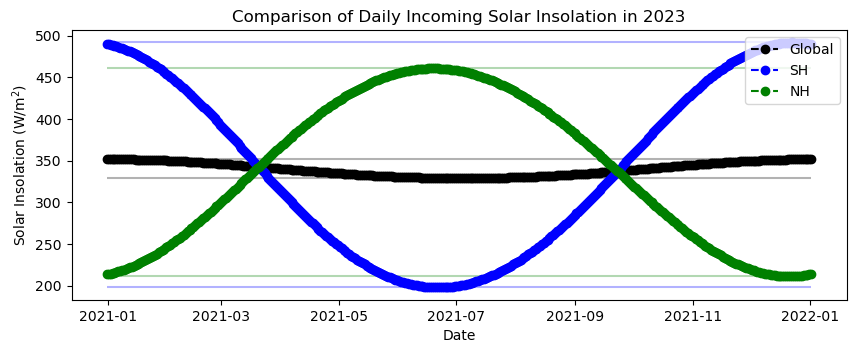

In [5]:
max_style = "solid"#(0, (3,5,1,5,1,5))
max_alpha = 0.3
plt.hlines(syn_21_nh.max(), syn_21_global.time[0], syn_21_global.time[-1],"g", linestyles=max_style, alpha=max_alpha)
plt.hlines(syn_21_nh.min(), syn_21_global.time[0], syn_21_global.time[-1], "g", linestyles=max_style, alpha=max_alpha)
plt.hlines(syn_21_sh.max(), syn_21_global.time[0], syn_21_global.time[-1], "b", linestyles=max_style, alpha=max_alpha)
plt.hlines(syn_21_sh.min(), syn_21_global.time[0], syn_21_global.time[-1], "b", linestyles=max_style, alpha=max_alpha)
plt.hlines(syn_21_global.max(), syn_21_global.time[0], syn_21_global.time[-1], "k", linestyles=max_style, alpha=max_alpha)
plt.hlines(syn_21_global.min(), syn_21_global.time[0], syn_21_global.time[-1], "k", linestyles=max_style, alpha=max_alpha)

plt.plot(syn_21_global.time, syn_21_global, "--ok", label="Global")
plt.plot(syn_21_nh.time, syn_21_sh, "--ob", label="SH")
plt.plot(syn_21_sh.time, syn_21_nh, "--og", label="NH")
plt.legend()
plt.ylabel("Solar Insolation (W/m$^2$)")
plt.xlabel("Date")
plt.title("Comparison of Daily Incoming Solar Insolation in 2023")

In [6]:
offsets = [0, 1, 1, 0.2422]
global_21_mean = make_annual_mean_from_daily_syn_data_four_offsets(syn_21_global, 2021, offsets=offsets)
nh_21_mean = make_annual_mean_from_daily_syn_data_four_offsets(syn_21_nh, 2021, offsets=offsets)
sh_21_mean = make_annual_mean_from_daily_syn_data_four_offsets(syn_21_sh, 2021, offsets=offsets)

print(f"Global Average: {global_21_mean} W/m^2")
print(f"Global Max:{syn_21_global.max().values} W/m^2")
print(f"Global Min:{syn_21_global.min().values} W/m^2")
print()
print(f"NH Average: {nh_21_mean} W/m^2")
print(f"NH Max:{syn_21_nh.max().values} W/m^2")
print(f"NH Min:{syn_21_nh.min().values} W/m^2")
print()
print(f"SH Average: {sh_21_mean} W/m^2")
print(f"SH Max:{syn_21_sh.max().values} W/m^2")
print(f"SH Min:{syn_21_sh.min().values} W/m^2")

Global Average: 340.0027396440026 W/m^2
Global Max:351.73790453465915 W/m^2
Global Min:328.89233090880987 W/m^2

NH Average: 340.001781345561 W/m^2
NH Max:460.6350289953482 W/m^2
NH Min:211.2887022938393 W/m^2

SH Average: 340.0036979443481 W/m^2
SH Max:491.73986067026306 W/m^2
SH Min:197.9217045623267 W/m^2


# Calculate the Calender Year Average

In [12]:
global_21_cal_annual = syn_21_global.groupby("time.year").mean()[1].values
nh_21_cal_annual = syn_21_nh.groupby("time.year").mean()[1].values
sh_21_cal_annual = syn_21_sh.groupby("time.year").mean()[1].values
print(f"Global Calender Year Average: {global_21_cal_annual} W/m^2")
print(f"NH Calender Year Average: {nh_21_cal_annual} W/m^2")
print(f"SH Calender Year Average: {sh_21_cal_annual} W/m^2")

Global Calender Year Average: 339.9949717900602 W/m^2
NH Calender Year Average: 340.0853750886274 W/m^2
SH Calender Year Average: 339.90456831067604 W/m^2


# Calculate the 2021 Average from Monthly Data

In [29]:
syn_21_monthly = syn_21.resample(time="1M").mean()
syn_21_global_monthly = apply_spatial_weights(syn_21_monthly, low_lat=-90, high_lat=90)
syn_21_nh_monthly = apply_spatial_weights(syn_21_monthly, low_lat=0, high_lat=90)
syn_21_sh_monthly = apply_spatial_weights(syn_21_monthly, low_lat=-90, high_lat=0)

# Using a 14 Month Average to account for the Leap Year
global_21_monthly_mean = apply_time_averaging(syn_21_global_monthly, averaging_method=3)
nh_21_monthly_mean = apply_time_averaging(syn_21_nh_monthly, averaging_method=3)
sh_21_monthly_mean = apply_time_averaging(syn_21_sh_monthly, averaging_method=3)

print(f"Global Monthly Average: {global_21_monthly_mean.values[0]} W/m^2")
print(f"NH Monthly Average: {nh_21_monthly_mean.values[0]} W/m^2")
print(f"SH Monthly Average: {sh_21_monthly_mean.values[0]} W/m^2")

Global Monthly Average: 340.00275595941986 W/m^2
NH Monthly Average: 340.00156568307955 W/m^2
SH Monthly Average: 340.003946238128 W/m^2


# Calculate the 2004 to 2014 Average
First with good averaging

In [21]:
comparative_average = [0,0,0]
syn_full_global = apply_spatial_weights(syn_full, low_lat=-90, high_lat=90)
syn_full_nh = apply_spatial_weights(syn_full, low_lat=0, high_lat=90)
syn_full_sh = apply_spatial_weights(syn_full, low_lat=-90, high_lat=0)
offsets_set = [[0, 0.2422, 1, 0], [0, 1, 1, 0.2422], [0, 1-0.2422, 1, 2*0.2422], [0, 1-2*0.2422, 1, 3*0.2422]]
for year in range(2004, 2015):
    modulo = year % 4
    offsets = offsets_set[modulo]
    comparative_average[0] += make_annual_mean_from_daily_syn_data_four_offsets(syn_full_global, year, offsets=offsets)
    comparative_average[1] += make_annual_mean_from_daily_syn_data_four_offsets(syn_full_nh, year, offsets=offsets)
    comparative_average[2] += make_annual_mean_from_daily_syn_data_four_offsets(syn_full_sh, year, offsets=offsets)
    
comparative_average = np.array(comparative_average) / 11
print(comparative_average)

[339.97641002 339.97764436 339.97517568]


Then with the calender year average

In [22]:
syn_full_global_annual = syn_full_global.groupby("time.year").mean()
syn_full_nh_annual = syn_full_nh.groupby("time.year").mean()
syn_full_sh_annual = syn_full_sh.groupby("time.year").mean()

o4_14_global = syn_full_global_annual.sel(year=slice(2004, 2014)).mean().values
o4_14_nh = syn_full_nh_annual.sel(year=slice(2004, 2014)).mean().values
o4_14_sh = syn_full_sh_annual.sel(year=slice(2004, 2014)).mean().values

print(f"2004-2014 Global Average: {o4_14_global} W/m^2")
print(f"2004-2014 NH Average: {o4_14_nh} W/m^2")
print(f"2004-2014 SH Average: {o4_14_sh} W/m^2")

2004-2014 Global Average: 339.9773676415588 W/m^2
2004-2014 NH Average: 339.9672588131996 W/m^2
2004-2014 SH Average: 339.987476490123 W/m^2
